# Differential gene expression and GO term enrichment analysis

In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from insitupy import InSituData, CACHE

c:\Users\ge37voy\AppData\Local\miniconda3\envs\insitupy\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Load Xenium data into `InSituData` object

Now the Xenium data can be parsed by providing the data path to the `InSituPy` project folder.

In [4]:
# read data
insitupy_project = Path(CACHE / "out/demo_insitupy_project")
xd = InSituData.read(insitupy_project)

# load modalities
xd.load_images()
xd.load_cells()
xd.load_annotations()

In [5]:
xd

InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		C:\Users\ge37voy\.cache\InSituPy\out\demo_insitupy_project

    ➤ images
       CD20:	(25778, 35416)
       HE:	(25778, 35416, 3)
       HER2:	(25778, 35416)
       nuclei:	(25778, 35416)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 156447 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc_sub_final', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_sub_final_colors', 'cell_type_publ_colors', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'umap'
               obsm: 'X_pca', 'X_umap', 'annotations', 'regions', 'spatial'
             

### Visualize annotations
<img src="../../demo_data/demo_screenshots/napari_regions_annotations.jpg" class="center"/>

In [6]:
xd.show()

2025-11-06 11:23:21 | [WARNING] QWindowsWindow::setGeometry: Unable to set geometry 1629x983+116+36 (frame: 1651x1039+105-9) on QWidgetWindow/"_QtMainWindowClassWindow" on "\\.\DISPLAY1". Resulting geometry: 2446x1477+119+50 (frame: 2468x1533+108+5) margins: 11, 45, 11, 11 minimum size: 385x500 MINMAXINFO maxSize=0,0 maxpos=0,0 mintrack=600,806 maxtrack=0,0)


## Perform sample-level differential gene expression analysis using `InSituData`

In [7]:
from insitupy.tools import dge

### Scenario 1: Comparison of two annotations within one dataset

In [8]:
dge_results = dge(
    target=xd,
    target_annotation_tuple=("Demo", "Tumor cells"),
    ref_annotation_tuple=("Demo", "Stroma"),
    ref=None,
    exclude_ambiguous_assignments=True
    )

Exclude ambiguously assigned cells...
Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


Results are saved in a `DiffExprResults` class. The main DGE results are saved in `.main`:

In [9]:
print(dge_results)
print(dge_results.main)

<DiffExprResults main=297 genes, neighbors=False>
         log2foldchange           padj      scores  neg_log10_pvals
gene                                                               
TACSTD2        4.258287  1.000000e-300  228.485779            300.0
KRT7           3.639654  1.000000e-300  206.441269            300.0
KRT8           4.133759  1.000000e-300  206.435577            300.0
EPCAM          3.372502  1.000000e-300  170.650497            300.0
CDH1           3.154814  1.000000e-300  142.136597            300.0
...                 ...            ...         ...              ...
MMP2          -4.745604  1.000000e-300 -139.529953            300.0
POSTN         -4.376478  1.000000e-300 -174.575211            300.0
CXCL12        -5.083491  1.000000e-300 -182.173859            300.0
CCDC80        -5.120635  1.000000e-300 -184.673721            300.0
LUM           -4.326242  1.000000e-300 -193.902039            300.0

[297 rows x 4 columns]


Information about the DGE analysis configuration can be found in `.config`:

In [10]:
print(dge_results.config)

DiffExprConfigCollector(
  General:
    mode: single-cell
    method_params: {'groupby': 'DGE_COMPARISON_COLUMN', 'reference': 'REFERENCE', 'method': 't-test', 'use_raw': False, 'layer': None, 'corr_method': 'benjamini-hochberg'}
    cells_layer: None
    exclude_ambiguous_assignments: True
  Target:
    annotation: Tumor cells
    cell_type: None
    region: None
    cell_number: 19689
    name: None
    metadata: None
  Reference:
    annotation: Stroma
    cell_type: None
    region: None
    cell_number: 11707
    name: None
    metadata: None
)


The results can be saved and read as follows:

In [11]:
dge_results.save("out/dge_results", overwrite=True)

In [12]:
dge_results.read("out/dge_results")

<DiffExprResults main=297 genes, neighbors=False>

A volcano plot can be generated using the `volcano()` plotting function. By setting `show_config=True`, one can also display the settings of the DGE analysis:

In [13]:
from insitupy.plotting import volcano

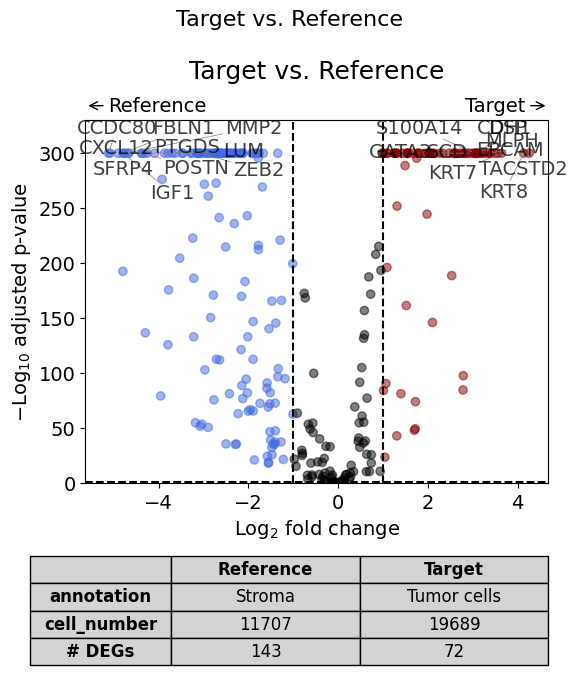

In [15]:
volcano(
    dge_results,
    label_sortby="scores",
    label_top_n=10,
    title="Target vs. Reference",
    show_config=True,
    )

### Scenario 2: Comparison of two annotations within one dataset - restrict analysis to a specific region

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


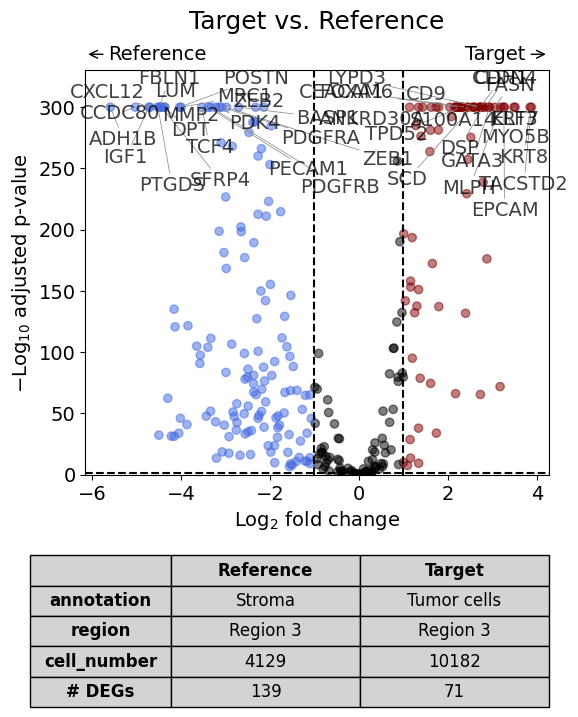

In [16]:
# do differential gene expression analysis
dge_results = dge(
    target=xd,
    target_annotation_tuple=("Demo", "Tumor cells"),
    ref_annotation_tuple=("Demo", "Stroma"),
    ref=None,
    target_region_tuple=("Demo", "Region 3"),
    ref_region_tuple="same",
    exclude_ambiguous_assignments=True, # if a cell is assigned to both the annotation and the reference, it is used only for the annotation
)

# plot volcano
volcano(dge_results, label_sortby="scores", show_config=True)

### Scenario 3: Comparison of two different cell types each in a different annotation within one dataset

This is the analysis shown in the publication in Figure 3F.

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


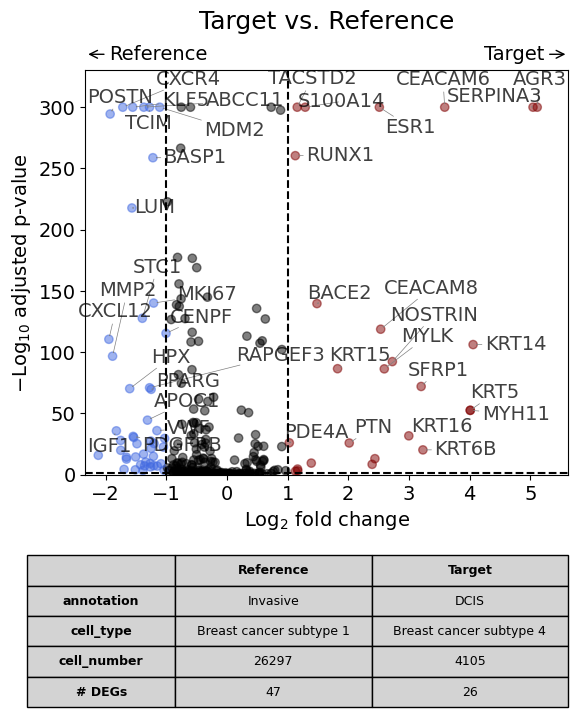

In [17]:
dge_results = dge(
    target=xd,
    target_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 4"),
    target_annotation_tuple=("Katja", "DCIS"),
    ref_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 1"),
    ref_annotation_tuple=("Katja", "Invasive"),
    ref=None,
    exclude_ambiguous_assignments=True, # if a cell is assigned to both the annotation and the reference, it is used only for the annotation
)

volcano(dge_results, label_sortby="scores", show_config=True)

### Scenario 4: Comparison of the same cell type in two different regions within one dataset

This is the analysis shown in the publication in Figure 3H.

In [18]:
xd.load_regions()

In [19]:
xd.regions

demo_regions:	3 regions, 3 classes ('Region1', 'Region2', 'Region3') ✔
TMA:	6 regions, 6 classes ('A-1', 'A-2', 'A-3', 'B-1', 'B-2', 'B-3') ✔
Demo:	3 regions, 3 classes ('Region 1', 'Region 2', 'Region 3') ✔
Katja:	4 regions, 4 classes ('Region 1', 'Region 2', 'Region 3', 'Region 4') 

Using CellData from MultiCellData layer 'main'.
Assigning key 'Katja'...


100%|██████████| 4/4 [00:00<00:00, 13.04it/s]


Added results to `.cells['main'].matrix.obsm['regions']
Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


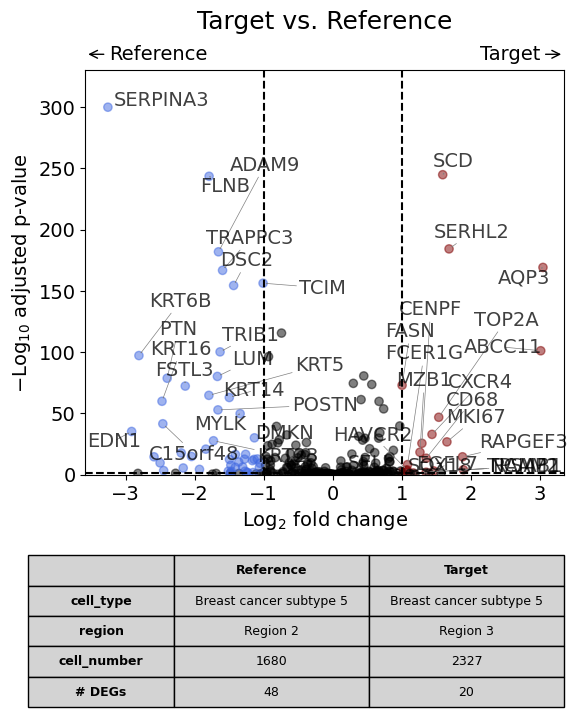

In [20]:
dge_results = dge(
    target=xd,
    target_cell_type_tuple=("cell_type_dc_sub_final", "Breast cancer subtype 5"),
    target_region_tuple=("Katja", "Region 3"),
    ref_cell_type_tuple="same",
    ref_region_tuple=("Katja", "Region 2"),
    ref=None,
    exclude_ambiguous_assignments=True, # if a cell is assigned to both the annotation and the reference, it is used only for the annotation
)

volcano(dge_results, label_sortby="scores", show_config=True)

## Experiment-level differential gene expression analysis

The clear structure of `InSituExperiment` lets us easily plan complex differential gene expression analysis across multiple samples. In the following, different Scenarios are shown how this can be done.

For more information on the `InSituExperiment` object see [here](../03_multisample_analysis/InSituPy_InSituExperiment.ipynb).

### Creating `InSituExperiment` object

In a first step the region annotations are used to split the dataset and create a `InSituExperiment` object.

In [21]:
from insitupy import InSituExperiment

In [22]:
exp = InSituExperiment.from_regions(
    data=xd,
    region_key="Demo",
    region_names=None # defaults to all regions
)
print(exp)

InSituExperiment with 3 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     a54b96c5  ++-++  0001879  Replicate 1       Demo    Region 1
1     12e99d99  ++-++  0001879  Replicate 1       Demo    Region 2
2     5f0467b6  ++-++  0001879  Replicate 1       Demo    Region 3


### Scenario 1: Comparison of cell types between two samples

#### Scenario 1.1: Using the `InSituData` objects

First, the datasets of interest are extracted from the `InSituExperiment` object and subsequently processed using the `dge` function. In contrast to the previous examples we use now two different datasets.

In [23]:
xd0 = exp.data[0]
xd1 = exp.data[1]
xd2 = exp.data[2]

##### With one reference dataset

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


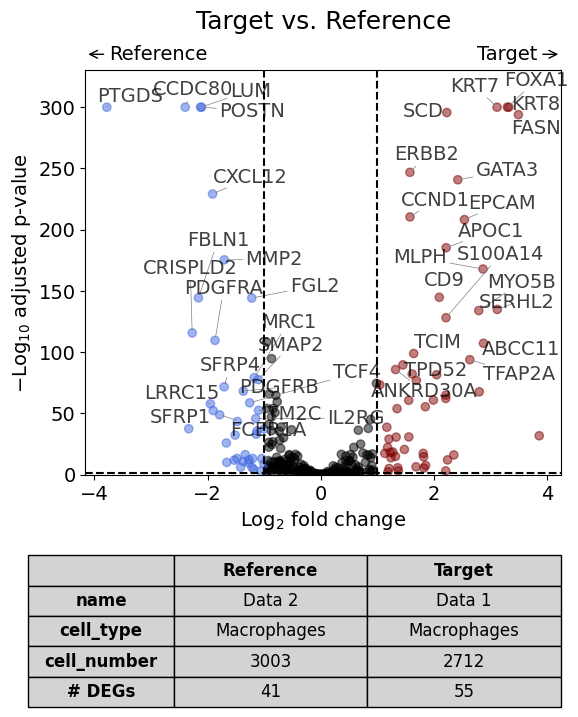

In [24]:
dge_results = dge(
    target=xd0,
    ref=xd1,
    target_name="Data 1",
    ref_name="Data 2",
    target_cell_type_tuple=("cell_type_dc_sub_final", "Macrophages"),
    ref_cell_type_tuple="same",
    exclude_ambiguous_assignments=False, # in this case we are sure that there are no duplicate assignments
)

volcano(dge_results, label_sortby="scores", show_config=True)

##### With list of reference datasets

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


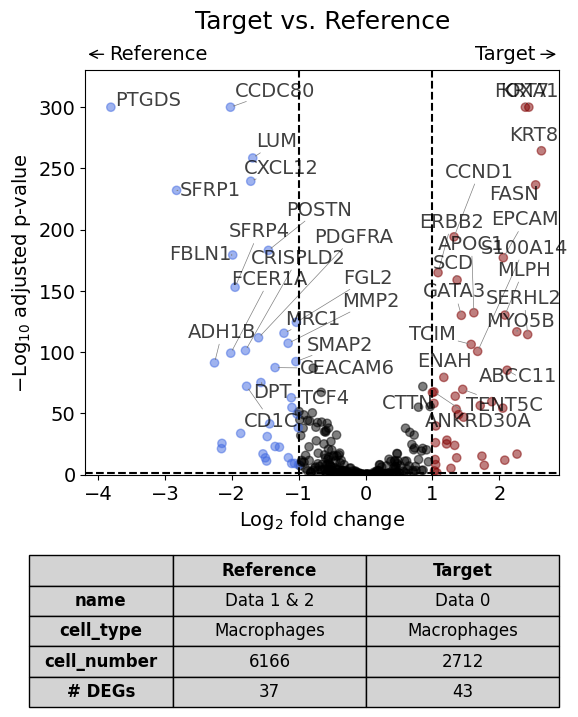

In [25]:
dge_results = dge(
    target=xd0,
    ref=[xd1, xd2],
    target_name="Data 0",
    ref_name="Data 1 & 2",
    target_cell_type_tuple=("cell_type_dc_sub_final", "Macrophages"),
    ref_cell_type_tuple="same",
    exclude_ambiguous_assignments=False, # if a cell is assigned to both the annotation and the reference, it is used only for the annotation
)

volcano(dge_results, label_sortby="scores", show_config=True)

##### Scenario 1.2: Using the `InSituExperiment` objects

Instead of extracting the `InSituData` objects first, we can also perform the DGE analysis directly on the `InSituExperiment` object using its `dge()` function.

This has the big advantage that the function has direct access to the metadata stored in `InSituExperiment`, which allows the results to be directly linked to the respective data via its unique ID. All metadata is stored in the `DiffExprResults` object.

In [26]:
exp.metadata

You are accessing a copy of the metadata. Changes to this DataFrame will not affect the internal metadata. Use `add_metadata_column()` or `append_metadata()` to add new information to the metadata.


,uid,slide_id,sample_id,region_key,region_name
0,a54b96c5,0001879,Replicate 1,Demo,Region 1
1,12e99d99,0001879,Replicate 1,Demo,Region 2
2,5f0467b6,0001879,Replicate 1,Demo,Region 3


##### With one reference dataset

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


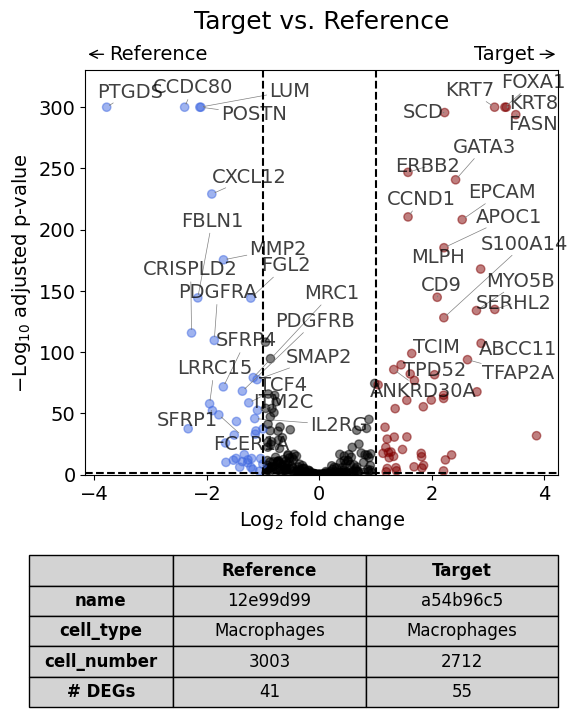

In [27]:
dge_results = exp.dge(
    target_id=0,
    ref_id=1,
    target_cell_type_tuple=("cell_type_dc_sub_final", "Macrophages"),
    ref_cell_type_tuple="same",
    exclude_ambiguous_assignments=False,
    # name_col="region_name"
)

volcano(dge_results, label_sortby="scores", show_config=True)

When using an `InSituExperiment` for differential gene expression analysis, all metadata of the individual samples is saved in `.config` of `DiffExprResults`:

In [28]:
print(dge_results.config)

DiffExprConfigCollector(
  General:
    mode: single-cell
    method_params: {'groupby': 'DGE_COMPARISON_COLUMN', 'reference': 'REFERENCE', 'method': 't-test', 'use_raw': False, 'layer': None, 'corr_method': 'benjamini-hochberg'}
    cells_layer: None
    exclude_ambiguous_assignments: False
  Target:
    annotation: None
    cell_type: Macrophages
    region: None
    cell_number: 2712
    name: a54b96c5
    metadata: {'uid': 'a54b96c5', 'slide_id': '0001879', 'sample_id': 'Replicate 1', 'region_key': 'Demo', 'region_name': 'Region 1'}
  Reference:
    annotation: None
    cell_type: Macrophages
    region: None
    cell_number: 3003
    name: 12e99d99
    metadata: {'uid': '12e99d99', 'slide_id': '0001879', 'sample_id': 'Replicate 1', 'region_key': 'Demo', 'region_name': 'Region 2'}
)


##### With list of reference datasets

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


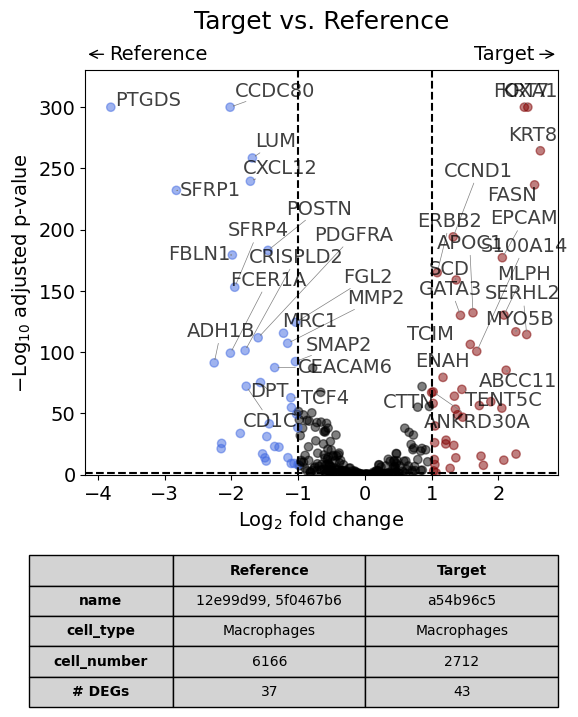

In [29]:
dge_results = exp.dge(
    target_id=0,
    ref_id=[1,2],
    target_cell_type_tuple=("cell_type_dc_sub_final", "Macrophages"),
    ref_cell_type_tuple="same",
    # name_col="region_name"
)

volcano(dge_results, label_sortby="scores", show_config=True)


##### Against all other datasets as reference using `"rest"` argument

This should result in the same plot as the previous analysis.

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


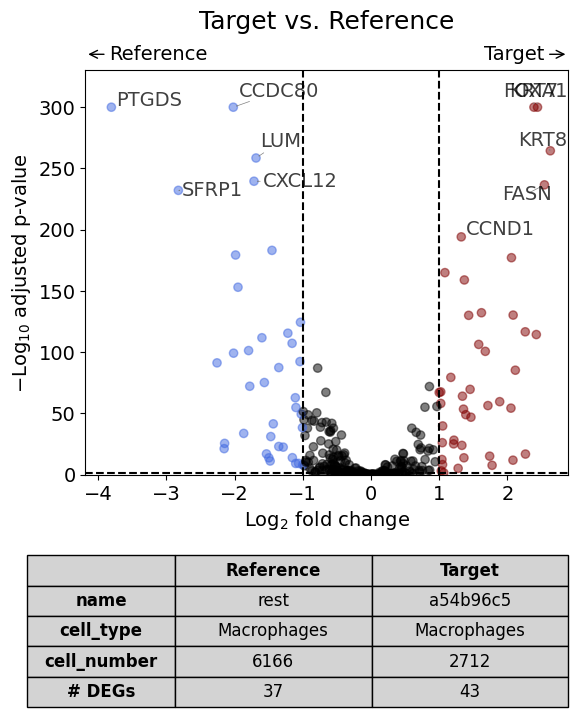

In [30]:
dge_results = exp.dge(
    target_id=0,
    ref_id="rest",
    target_cell_type_tuple=("cell_type_dc_sub_final", "Macrophages"),
    ref_cell_type_tuple="same",
    exclude_ambiguous_assignments=True,
)

volcano(
    dge_results,
    label_sortby="scores",
    show_config=True,
    label_top_n=5,
    savepath="figures/dge_demo_region1_vs_rest.pdf"
    )

Since "rest" can be a large list of files, the individual unique IDs are not shown in the config table. However, they are saved in `.config` of the `DiffExprResults`:

In [31]:
dge_results.config

DiffExprConfigCollector(
  General:
    mode: single-cell
    method_params: {'groupby': 'DGE_COMPARISON_COLUMN', 'reference': 'REFERENCE', 'method': 't-test', 'use_raw': False, 'layer': None, 'corr_method': 'benjamini-hochberg'}
    cells_layer: None
    exclude_ambiguous_assignments: True
  Target:
    annotation: None
    cell_type: Macrophages
    region: None
    cell_number: 2712
    name: a54b96c5
    metadata: {'uid': 'a54b96c5', 'slide_id': '0001879', 'sample_id': 'Replicate 1', 'region_key': 'Demo', 'region_name': 'Region 1'}
  Reference:
    annotation: None
    cell_type: Macrophages
    region: None
    cell_number: 6166
    name: rest
    metadata: {'uid': ['12e99d99', '5f0467b6'], 'slide_id': ['0001879', '0001879'], 'sample_id': ['Replicate 1', 'Replicate 1'], 'region_key': ['Demo', 'Demo'], 'region_name': ['Region 2', 'Region 3']}
)

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


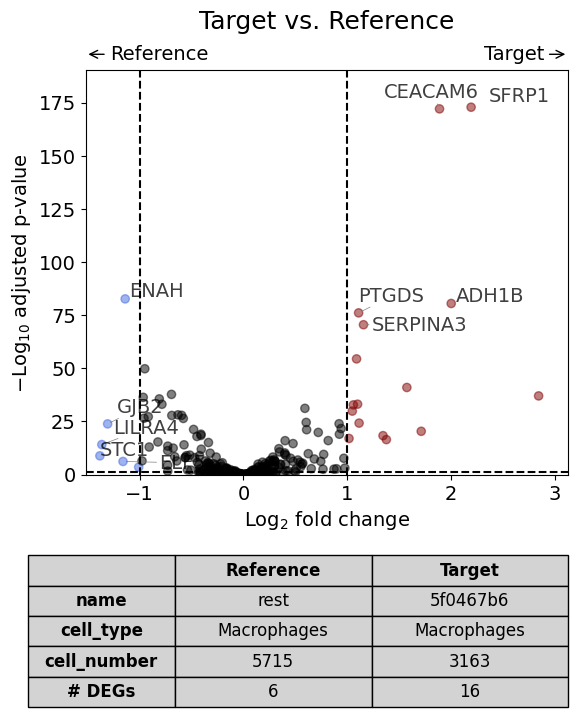

In [32]:
dge_results = exp.dge(
    target_id=2,
    ref_id="rest",
    target_cell_type_tuple=("cell_type_dc_sub_final", "Macrophages"),
    ref_cell_type_tuple="same",
    exclude_ambiguous_assignments=True
)

volcano(
    dge_results,
    label_sortby="scores",
    show_config=True,
    label_top_n=5,
    savepath="figures/dge_demo_region3_vs_rest.pdf"
    )

### Scenario 2: Comparison of cells within one annotation against all other annotations - all within the same dataset

#### Scenario 2.1: Perform analysis without specifying a cell type

This scenario is only uses one dataset but also works on the `InSituExperiment` level.

Exclude ambiguously assigned cells...
Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


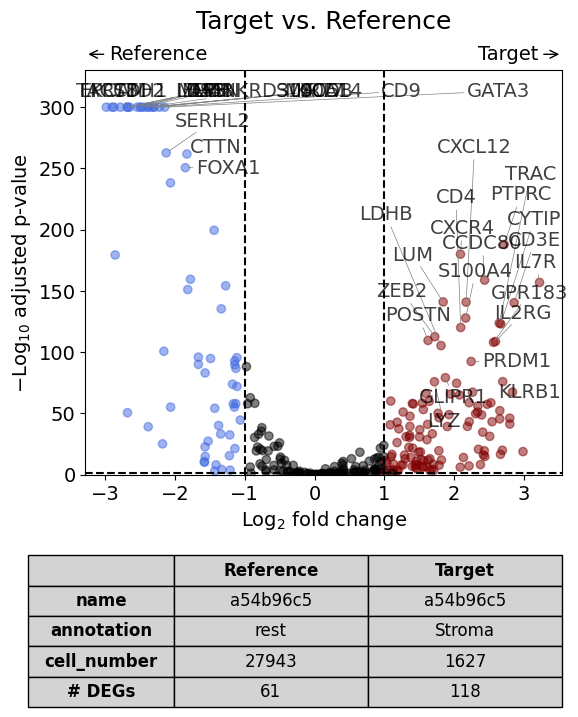

In [33]:
dge_results = exp.dge(
    target_id=0,
    target_annotation_tuple=("Demo", "Stroma"),
    ref_annotation_tuple="rest",
    exclude_ambiguous_assignments=True,
)

volcano(dge_results, label_sortby="scores", show_config=True)

#### Scenario 2.2: Perform analysis for one cell type only

This scenario is very similar to the first but the analysis is restricted to only one cell type (in this case Fibroblasts).

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.
10 [ 0.64773178 -0.93706954]
11 [0.22092932 0.89596077]
10 [-0.83572843 -0.27929984]
30 [ 0.2505746 -0.9840685]


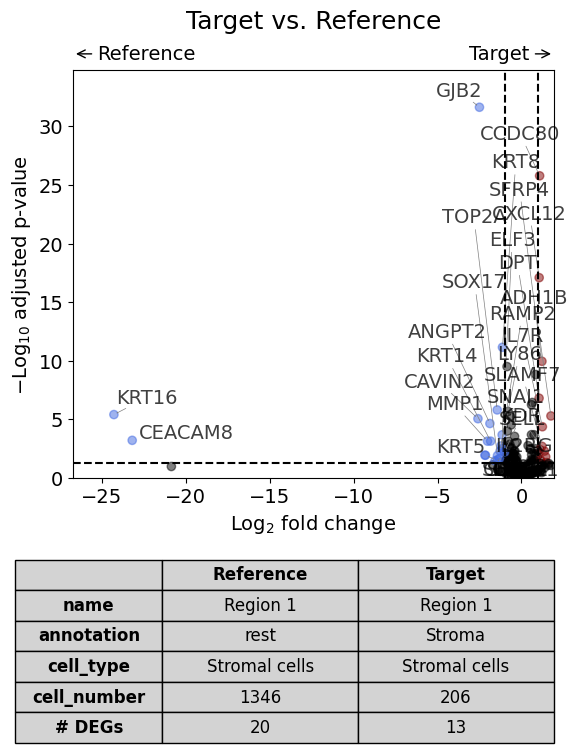

In [34]:
dge_results = exp.dge(
    target_id=0,
    target_annotation_tuple=("Demo", "Stroma"),
    ref_annotation_tuple="rest",
    target_cell_type_tuple=("cell_type_dc_sub_final", "Stromal cells"),
    ref_cell_type_tuple="same",
    name_col="region_name",
)

volcano(dge_results, label_sortby="scores", show_config=True)

### Scenario 3: Comparison of two annotations between two regions or datasets - restrict analysis to one cell type

Here we compare the gene expression of one particular cell type (Stromal cells) in one histological annotation (Stroma) between two datasets. Further, we save the plot as PDF and restrict the number of labelled genes to 5.

In [35]:
annotation = "Stroma"
cell_type = "Stromal cells"

In [38]:
dge_results = exp.dge(
    target_id=0,
    ref_id=1,
    target_annotation_tuple=("Demo", annotation),
    ref_annotation_tuple=("Demo", annotation),
    target_cell_type_tuple=("cell_type_dc_sub_final", cell_type),
    ref_cell_type_tuple="same",
)

Calculate differentially expressed genes with Scanpy's `rank_genes_groups` using 't-test'.


Sometimes low gene expression values lead to very large fold changes as can be seen in following plot. To exclude certain markers from the plot, one can remove them from `dge_results` or set `xlim` in `volcano`.

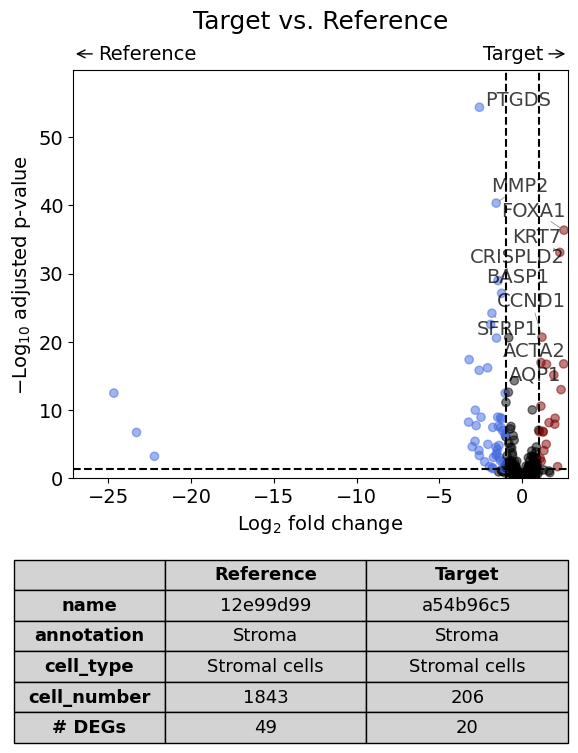

In [40]:
volcano(
    dge_results,
    label_sortby="scores",
    show_config=True,
    label_top_n=5,
    )

Setting boundaries on the x axis using the `xlim` argument:

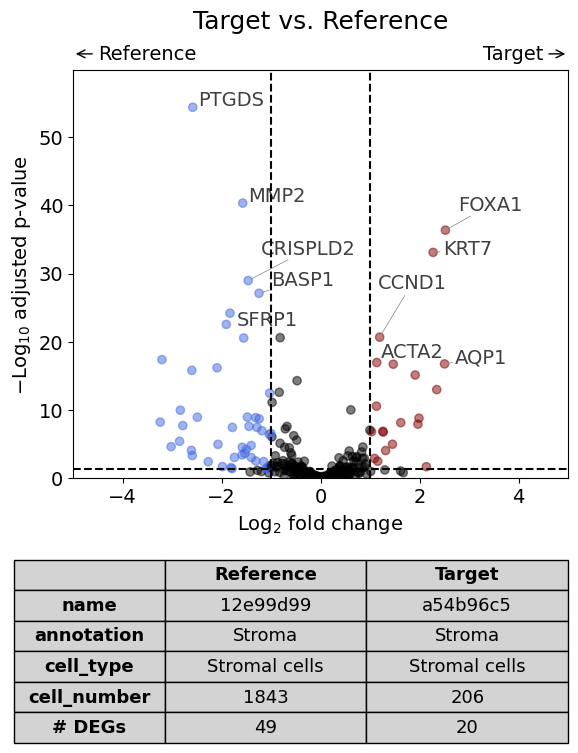

In [41]:

volcano(
    dge_results,
    label_sortby="scores",
    show_config=True,
    label_top_n=5,
    savepath="figures/volcano_demo.pdf",
    xlim=(-5,5)
    )

## GO term enrichment analysis

Gene ontology (GO) term enrichment analysis can be performed via three different analysis platforms: [g:Profiler](https://biit.cs.ut.ee/gprofiler/gost) and [Enrichr](https://maayanlab.cloud/Enrichr/).

As explained [here](https://biit.cs.ut.ee/gprofiler/page/docs#statistical_domain_scope) in case of panel-based technologies such as Xenium it is important to us a custom background gene list for the statistical analysis instead of all possible genes. Here, we used the overall gene list for this.

[STRINGdb](https://string-db.org/) is also implemented but does not allow to limit the background gene list. Therefore, this tool is not recommended to be used for Xenium data.

⚠️ **Attention**: Due to the low number of genes in a normal Xenium run, using GO term enrichment analysis with such datasets can be problematic. Please get in contact with statisticians to make sure it is ok to use this method with your data.

In [42]:
from insitupy.utils.go import GOEnrichment, get_up_down_genes
from insitupy.plotting.go import go_plot

In [48]:
genes_up, genes_down = get_up_down_genes(
    dge_results.main, pval_threshold=0.05, logfold_threshold=1)

In [49]:
background_genes = exp.data[0].cells.matrix.var_names.tolist()

In [52]:
# setup go term enrichment class
go = GOEnrichment()

# run go term enrichment analysis for up-regulated genes
go.gprofiler(target_genes=genes_up, key_added='up',
             top_n=20, organism="hsapiens", return_df=False,
             background=background_genes
             )
go.enrichr(target_genes=genes_up, key_added='up',
             top_n=20, organism="human", return_df=False,
             background=background_genes
             )

# for down-regulated genes
go.gprofiler(target_genes=genes_down, key_added='down',
             top_n=20, organism="hsapiens", return_df=False,
             background=background_genes
             )
go.enrichr(target_genes=genes_down, key_added='down',
             top_n=20, organism="human", return_df=False,
             background=background_genes
             )

The results are saved in the `GOEnrichment` class and can be accessed with the respective keys.

In [53]:
go

GOEnrichment analyses performed:
  gprofiler:
    - up
    - down
  enrichr:
    - up
    - down

Gprofiler does not return any significant results.

In [54]:
enrichment = go.results["gprofiler"]["up"]
enrichment.head()

,,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,Gene ratio,query,parents,intersections,evidences,Enrichment score


In [55]:
enrichment = go.results["gprofiler"]["down"]
enrichment.head()

,,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,Gene ratio,query,parents,intersections,evidences,Enrichment score


Enrichr does return significant results (before multiple testing correction).

In [56]:
enrichment = go.results["enrichr"]["down"]
enrichment.head()

source  \
query 0  GO_Biological_Process_2025   
      1  GO_Biological_Process_2025   
      2  GO_Biological_Process_2025   
      3  GO_Biological_Process_2025   
      4  GO_Biological_Process_2025   

                                                      name   P-value  \
query 0                      Fc Receptor Signaling Pathway  0.038175   
      1  Positive Regulation of Cold-Induced Thermogenesis  0.038175   
      2                Cytokine-Mediated Signaling Pathway  0.048466   
      3           Regulation of Cold-Induced Thermogenesis  0.054954   
      4                  Regulation of Signal Transduction  0.054954   

         Adjusted P-value  Old P-value  Old adjusted P-value  Odds Ratio  \
query 0          0.308416            0                     0   10.148148   
      1          0.308416            0                     0   10.148148   
      2          0.308416            0                     0    4.711765   
      3          0.308416            0                     0    7.583333   
      4          0.308416            0                     0    7.583333   

         Combined Score           intersections  Enrichment score      native  
query 0       33.139449          [PIGR, LILRA4]          0.510862  GO:0038093  
      1       33.139449          [OXTR, ADIPOQ]          0.510862  GO:0120162  
      2       14.262026  [CCL8, ADIPOQ, LILRA4]          0.510862  GO:0019221  
      3       22.001220          [OXTR, ADIPOQ]          0.510862  GO:0120161  
      4       22.001220         [ADIPOQ, NCAM1]          0.510862  GO:0009966

In [57]:
enrichment = go.results["enrichr"]["up"]
enrichment.head()

source  \
query 0  GO_Biological_Process_2025   
      1  GO_Biological_Process_2025   
      2  GO_Biological_Process_2025   
      3  GO_Biological_Process_2025   
      4  GO_Biological_Process_2025   

                                                      name   P-value  \
query 0  Regulation of Cell-Cell Adhesion Mediated by C...  0.004322   
      1                    Fatty Acid Biosynthetic Process  0.012440   
      2                                     Response to UV  0.012440   
      3                        Skeletal System Development  0.012440   
      4       Negative Regulation of Programmed Cell Death  0.023214   

         Adjusted P-value  Old P-value  Old adjusted P-value  Odds Ratio  \
query 0          0.192143            0                     0         inf   
      1          0.192143            0                     0   30.666667   
      2          0.192143            0                     0   30.666667   
      3          0.192143            0                     0   30.666667   
      4          0.192143            0                     0    6.806723   

         Combined Score         intersections  Enrichment score      native  
query 0             inf        [FOXA1, EPCAM]          0.716375  GO:2000047  
      1      134.529952           [SCD, FASN]          0.716375  GO:0006633  
      2      134.529952        [CCND1, PCLAF]          0.716375  GO:0009411  
      3      134.529952        [TFAP2A, STC1]          0.716375  GO:0001501  
      4       25.613576  [TFAP2A, TCIM, FASN]          0.716375  GO:0043069

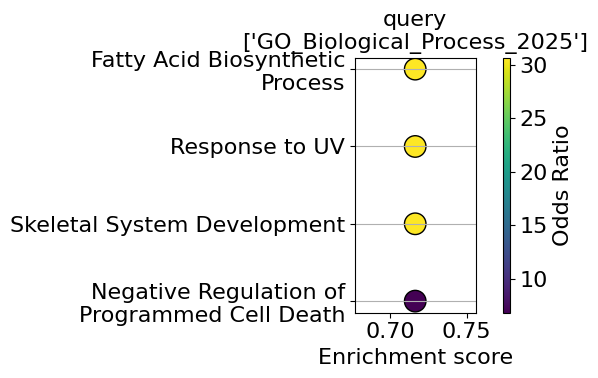

In [58]:
go_plot(enrichment=enrichment,
        style='dot',
        libraries='GO_Biological_Process_2025',
        color_key="Odds Ratio",
        max_to_plot=5,
        figsize=(6,4),
        #savepath="figures/go_demo.pdf"
        )